In [1]:
# Import aller Bibliotheken
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score

from PIL import Image
import io
import os
import glob
import base64
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras import preprocessing
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.losses import mse, binary_crossentropy
print(tf.__version__)

2.13.1


In [2]:
# Trainings- und Validierungsdatensatz laden
m14x14 = pd.read_csv('class_128_400_14x14.csv')
m14x14.head(6)

,label,p0,p1,p2,p3,p4,p5,p6,p7,p8,...,p186,p187,p188,p189,p190,p191,p192,p193,p194,p195
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Datensatz aufbereiten: Skalieren auf Wertebereich zwischen 0 und 1 UND Splitten in Train und Test.
feature_spalten = []
for i in range(0, 196): 
    feature_spalten.append("p"+str(i))

X = m14x14[feature_spalten]
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
y = m14x14['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # 70% training and 30% test

In [4]:
tf.keras.backend.clear_session()

# Dimensionen des Inputs
input_dim = X_train.shape[1]

# Dimensionen des latenten Raums
latent_dim = 2

# Encoder
inputs = layers.Input(shape=(input_dim,)) # 14x14 Pixel
h = layers.Dense(128, activation='relu')(inputs)
h = layers.Dense(64, activation='relu')(h)
h = layers.Dense(32, activation='relu')(h)
h = layers.BatchNormalization()(h)

# Latente Variable: Mean und Log-Varianz (sigma)
z_mean = layers.Dense(latent_dim, name='z_mean')(h)
z_log_var = layers.Dense(latent_dim, name='z_log_var')(h)

In [5]:
# Sampling Layer
def sampling(args):
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_log_var])


In [6]:
# Decoder
decoder_h1 = layers.Dense(32, activation='relu')
decoder_h2 = layers.Dense(64, activation='relu')
decoder_h3 = layers.Dense(128, activation='relu')
decoder_mean = layers.Dense(input_dim, activation='sigmoid') # Rekonstruierte Bilder

h_decoded = decoder_h1(z)
h_decoded = decoder_h2(h_decoded)
h_decoded = decoder_h3(h_decoded)
outputs = decoder_mean(h_decoded)

decoder = Model(z, outputs, name='decoder')

In [7]:
vae = Model(inputs, outputs)

vae.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 196)]                0         []                            
                                                                                                  
 dense (Dense)               (None, 128)                  25216     ['input_1[0][0]']             
                                                                                                  
 dense_1 (Dense)             (None, 64)                   8256      ['dense[0][0]']               
                                                                                                  
 dense_2 (Dense)             (None, 32)                   2080      ['dense_1[0][0]']             
                                                                                              

In [8]:
import keras.backend as K
# Loss Function: Rekonstruktionsverlust + KL-Divergenz
kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
reconstruction_loss = K.sum(K.square(outputs-inputs))

vae_loss = reconstruction_loss + kl_loss

vae.add_loss(vae_loss)
vae.compile(optimizer='adam')

In [9]:
# Training
history = vae.fit(X_train, X_train, epochs=100, batch_size=12, validation_data=(X_test, X_test))


Epoch 1/100
70/70 [==============================] - 2s 8ms/step - loss: 251.4249 - val_loss: 152.3285
Epoch 2/100
70/70 [==============================] - 0s 4ms/step - loss: 130.8985 - val_loss: 133.1345
Epoch 3/100
70/70 [==============================] - 0s 5ms/step - loss: 123.5476 - val_loss: 120.0956
Epoch 4/100
70/70 [==============================] - 0s 4ms/step - loss: 118.9693 - val_loss: 113.4571
Epoch 5/100
70/70 [==============================] - 0s 4ms/step - loss: 114.4970 - val_loss: 105.8796
Epoch 6/100
70/70 [==============================] - 0s 5ms/step - loss: 114.5205 - val_loss: 103.4681
Epoch 7/100
70/70 [==============================] - 0s 4ms/step - loss: 110.9427 - val_loss: 100.8235
Epoch 8/100
70/70 [==============================] - 0s 4ms/step - loss: 108.2999 - val_loss: 99.5831
Epoch 9/100
70/70 [==============================] - 0s 4ms/step - loss: 107.9173 - val_loss: 99.2164
Epoch 10/100
70/70 [==============================] - 0s 4ms/step - loss: 1

70/70 [==============================] - 0s 5ms/step - loss: 91.6985 - val_loss: 81.9891
Epoch 82/100
70/70 [==============================] - 0s 4ms/step - loss: 93.4481 - val_loss: 83.9333
Epoch 83/100
70/70 [==============================] - 0s 5ms/step - loss: 91.2472 - val_loss: 83.5286
Epoch 84/100
70/70 [==============================] - 0s 5ms/step - loss: 92.8601 - val_loss: 82.6777
Epoch 85/100
70/70 [==============================] - 0s 5ms/step - loss: 90.7777 - val_loss: 82.2997
Epoch 86/100
70/70 [==============================] - 0s 4ms/step - loss: 91.3635 - val_loss: 83.3604
Epoch 87/100
70/70 [==============================] - 0s 5ms/step - loss: 92.3701 - val_loss: 84.1713
Epoch 88/100
70/70 [==============================] - 0s 4ms/step - loss: 93.3853 - val_loss: 82.3361
Epoch 89/100
70/70 [==============================] - 0s 5ms/step - loss: 91.7613 - val_loss: 81.9322
Epoch 90/100
70/70 [==============================] - 0s 5ms/step - loss: 91.5571 - val_loss: 8

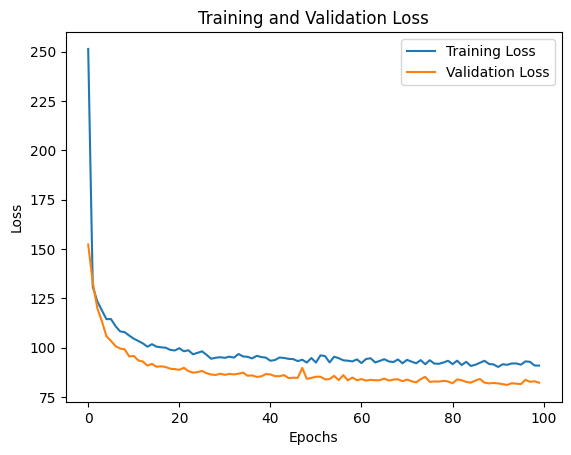

In [10]:
# Plotten des Trainings- und Validierungsverlusts
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

27/27 [==============================] - 0s 1ms/step


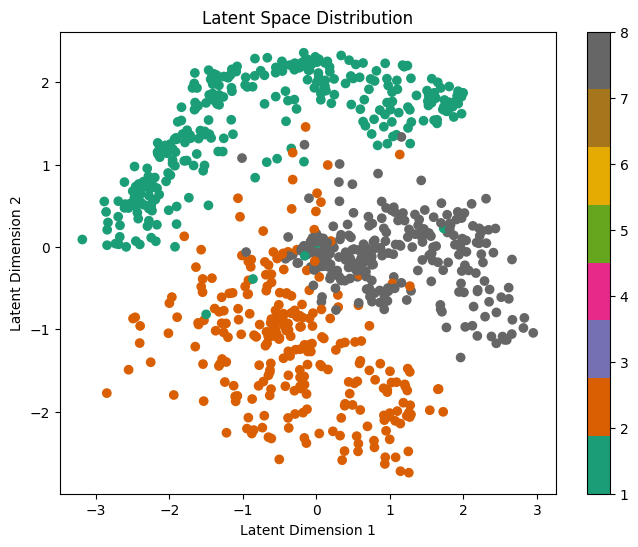

In [11]:
# Encoder-Modell definieren, um den latenten Raum zu projizieren
encoder = Model(inputs, z_mean)  # Hier verwenden wir z_mean, um die latente Verteilung zu visualisieren

# Projektion der Daten in den latenten Raum
z_train = encoder.predict(X_train)

# Plotten des latenten Raumes
plt.figure(figsize=(8, 6))
plt.scatter(z_train[:, 0], z_train[:, 1], c=y_train, cmap='Dark2')
plt.colorbar()
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('Latent Space Distribution')
plt.show()

1/1 [==============================] - 0s 150ms/step


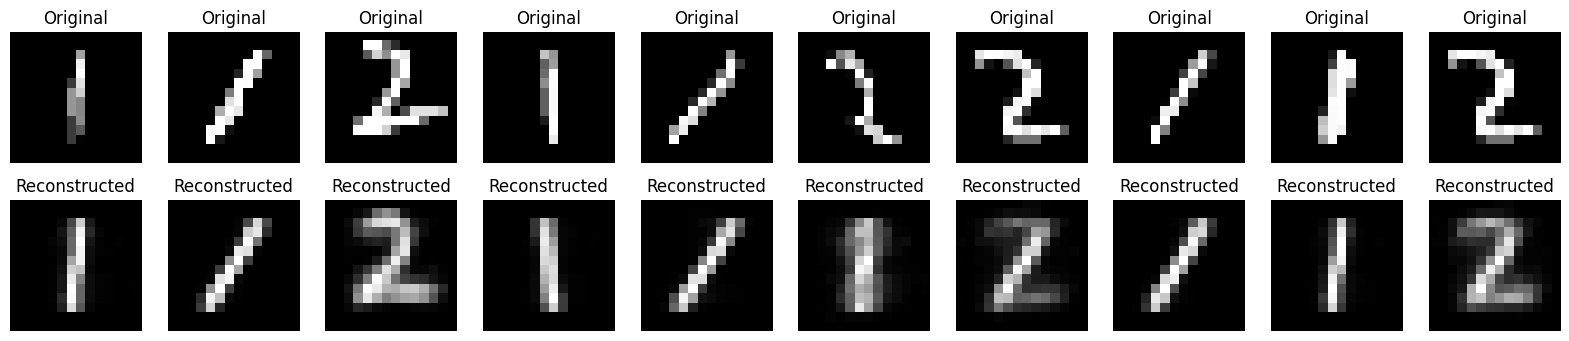

In [12]:
# Einige Testbilder auswählen
num_samples = 10
random_indices = np.random.choice(X_test.shape[0], num_samples)

# Rekonstruktion der ausgewählten Bilder
reconstructions = vae.predict(X_test[random_indices])

# Originalbilder und rekonstruktionen plotten
plt.figure(figsize=(20, 4))
for i in range(num_samples):
    # Originalbild
    ax = plt.subplot(2, num_samples, i + 1)
    plt.imshow(X_test[random_indices[i]].reshape(14, 14), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    # Rekonstruiertes Bild
    ax = plt.subplot(2, num_samples, i + 1 + num_samples)
    plt.imshow(reconstructions[i].reshape(14, 14), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

1/1 [==============================] - 0s 47ms/step


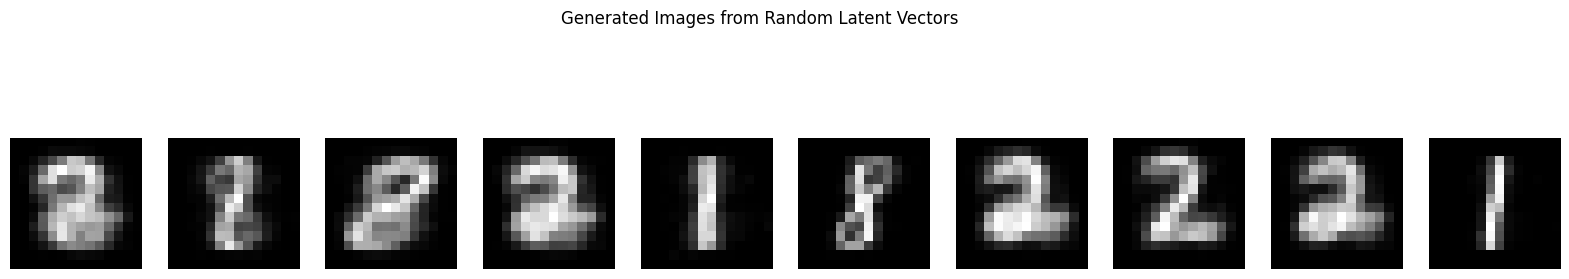

In [13]:
# Zufällige Punkte im latenten Raum generieren
n = 10  # Anzahl der zu generierenden Bilder
random_latent_vectors = np.random.normal(size=(n, latent_dim))

# Durch den Decoder gehen, um neue Bilder zu generieren
generated_images = decoder.predict(random_latent_vectors)

# Generierte Bilder plotten
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.imshow(generated_images[i].reshape(14, 14), cmap='gray')
    plt.axis('off')

plt.suptitle('Generated Images from Random Latent Vectors')
plt.show()

12/12 [==============================] - 0s 2ms/step


C:\04_Portables\EDUPYTER\apps\lib\site-packages\sklearn\manifold\_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\04_Portables\EDUPYTER\apps\lib\site-packages\sklearn\manifold\_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


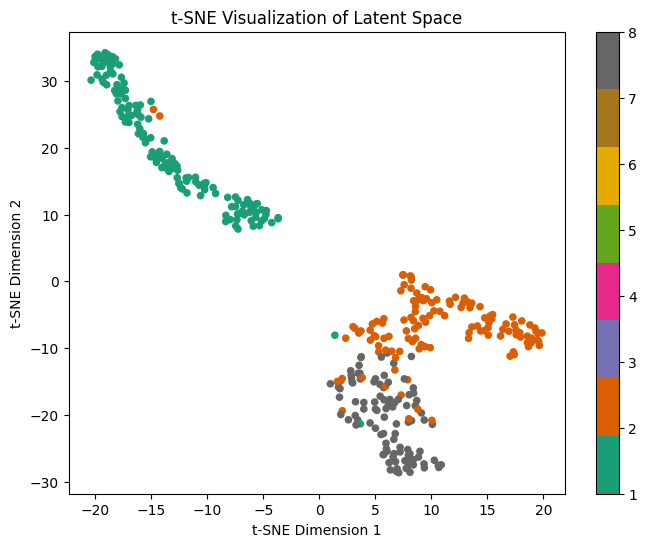

In [14]:
# 1. Importieren Sie die notwendigen Bibliotheken
from sklearn.manifold import TSNE

# 2. Extrahieren der latenten Variablen mit dem Encoder-Modell
z_mean = encoder.predict(X_test)

# 3. Anwenden von t-SNE auf die latenten Variablen
tsne = TSNE(n_components=2, random_state=42)
z_tsne = tsne.fit_transform(z_mean)

# 4. Visualisieren der t-SNE-Transformation
plt.figure(figsize=(8, 6))
plt.scatter(z_tsne[:, 0], z_tsne[:, 1], c=y_test, cmap='Dark2', s=20)
plt.colorbar()
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE Visualization of Latent Space')
plt.show()